<a href="https://colab.research.google.com/github/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/blob/main/Lab%2015/%5BLab_15%5D_Lab%5D_From_Regression_to_Machine_Learning_%E2%80%94_The_Bias_Variance_Tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete ✓')

Setup complete ✓


In [4]:
n_train = 50
n_test = 200
noise_std = 0.3

def true_function(x):
    return np.sin(2 * np.pi * x)

# Training data
x_train = np.sort(np.random.uniform(0, 1, n_train))
y_train = true_function(x_train) + np.random.normal(0, noise_std, n_train)

# Test data (separate - the model never sees this)
x_test = np.sort(np.random.uniform(0, 1, n_test))
y_test = true_function(x_test) + np.random.normal(0, noise_std, n_test)

x_plot = np.linspace(0, 1, 300)

print(f'Training set: {n_train} observations')
print(f'Test set:     {n_test} observations')
print(f'Noise std:    {noise_std} (sigma^2 = {noise_std**2:.2f})')

Training set: 50 observations
Test set:     200 observations
Noise std:    0.3 (sigma^2 = 0.09)


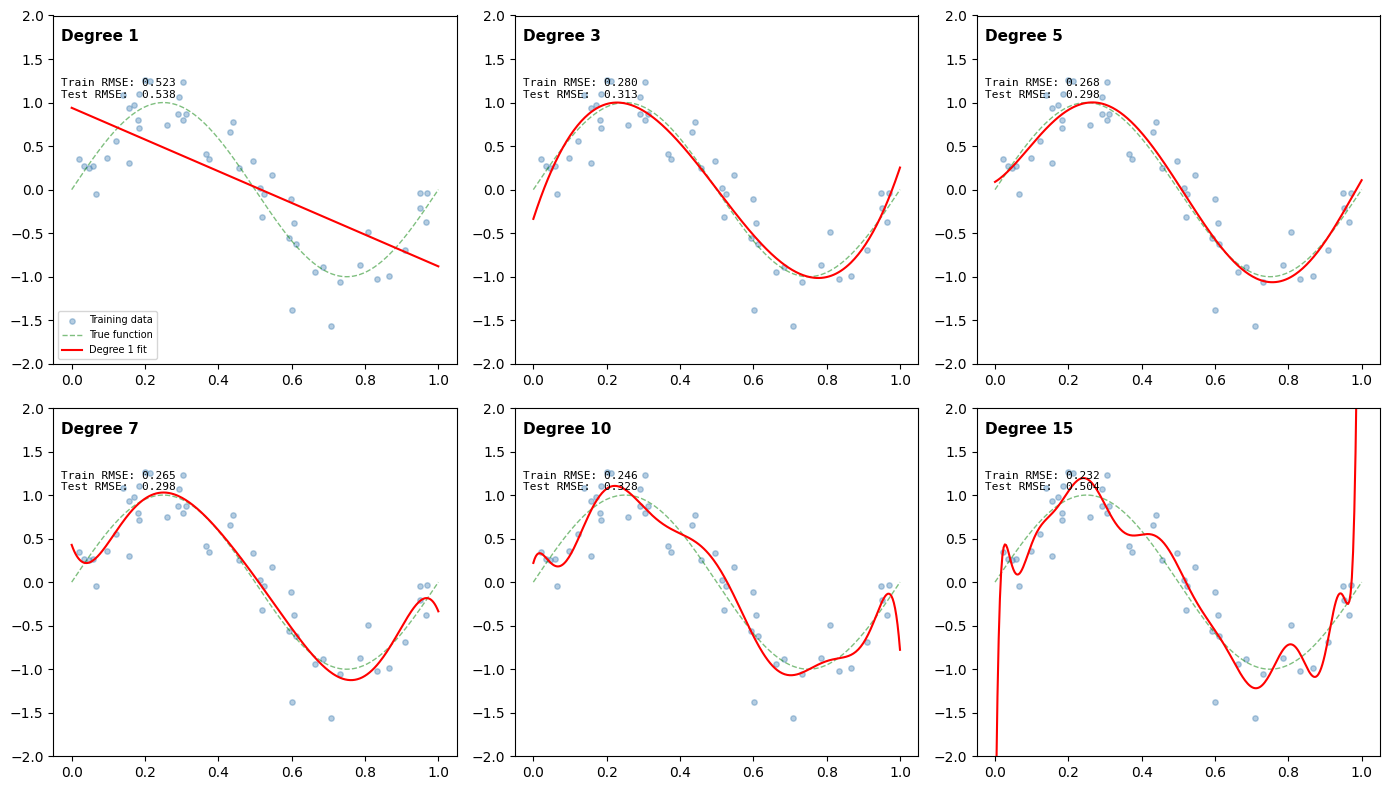

In [5]:
degrees = [1, 3, 5, 7, 10, 15]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, d in enumerate(degrees):
    ax = axes[idx]
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    y_pred_plot = model.predict(x_plot.reshape(-1, 1))

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))

    ax.scatter(x_train, y_train, alpha=0.4, s=15, color='steelblue',
               label='Training data')
    ax.plot(x_plot, true_function(x_plot), 'g--', alpha=0.5,
            linewidth=1, label='True function')
    ax.plot(x_plot, y_pred_plot, 'r-', linewidth=1.5,
            label=f'Degree {d} fit')
    ax.set_ylim(-2, 2)
    ax.text(0.02, 0.96, f'Degree {d}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.02, 0.82,
            f'Train RMSE: {train_rmse:.3f}\nTest RMSE:  {test_rmse:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            fontfamily='monospace')
    if idx == 0:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

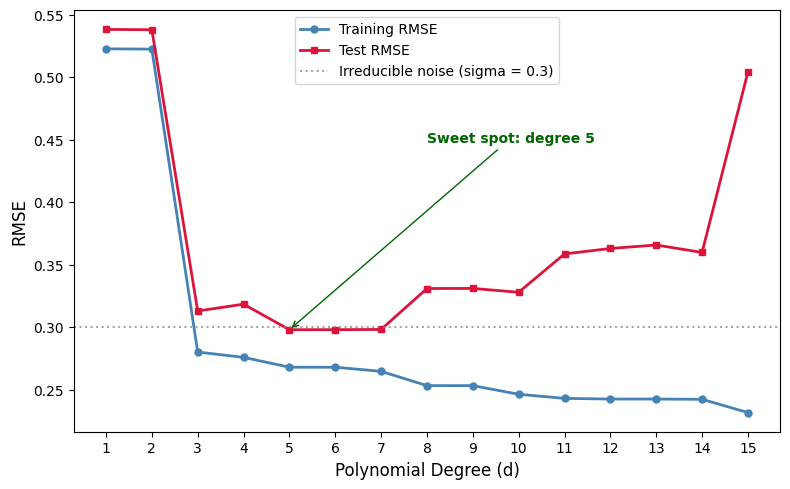

In [6]:
all_degrees = range(1, 16)
train_errors = []
test_errors = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(all_degrees), train_errors, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Training RMSE')
ax.plot(list(all_degrees), test_errors, 's-', color='crimson',
        linewidth=2, markersize=5, label='Test RMSE')
ax.axhline(y=noise_std, color='gray', linestyle=':', alpha=0.7,
           label=f'Irreducible noise (sigma = {noise_std})')

best_degree = list(all_degrees)[np.argmin(test_errors)]
best_test_rmse = min(test_errors)
ax.annotate(f'Sweet spot: degree {best_degree}',
            xy=(best_degree, best_test_rmse),
            xytext=(best_degree + 3, best_test_rmse + 0.15),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
def manual_kfold_cv(x, y, degree, k=5):
    """
    Perform k-fold cross-validation for polynomial regression.

    Parameters
    ----------
    x : np.ndarray, shape (n,)
    y : np.ndarray, shape (n,)
    degree : int
    k : int

    Returns
    -------
    float : Mean CV RMSE
    np.ndarray : Per-fold RMSE values
    """
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_errors = []

    for i in range(k):
        # Create test and train indices for this fold
        test_idx = folds[i]
        train_idx = np.concatenate(
            [folds[j] for j in range(k) if j != i]
        )

        # Split data
        x_fold_train, y_fold_train = x[train_idx], y[train_idx]
        x_fold_test, y_fold_test = x[test_idx], y[test_idx]

        # Fit polynomial model on training fold
        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            LinearRegression()
        )
        model.fit(x_fold_train.reshape(-1, 1), y_fold_train)

        # Predict on test fold and compute RMSE
        y_pred = model.predict(x_fold_test.reshape(-1, 1))
        fold_rmse = np.sqrt(mean_squared_error(
            y_fold_test, y_pred))
        fold_errors.append(fold_rmse)

    fold_errors = np.array(fold_errors)
    return fold_errors.mean(), fold_errors

In [8]:
from sklearn.model_selection import cross_val_score

model_d3 = make_pipeline(
    PolynomialFeatures(3, include_bias=False),
    LinearRegression()
)

# cross_val_score returns NEGATIVE MSE (sklearn convention)
cv_scores = cross_val_score(
    model_d3, x_train.reshape(-1, 1), y_train,
    cv=5, scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(-cv_scores)

print(f'sklearn 5-fold CV RMSE (degree 3): '
      f'{cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')
print(f'Per-fold RMSE: {cv_rmse}')

sklearn 5-fold CV RMSE (degree 3): 0.7226 +/- 0.8230
Per-fold RMSE: [0.33804966 0.22992916 0.24712496 0.43602712 2.36206012]


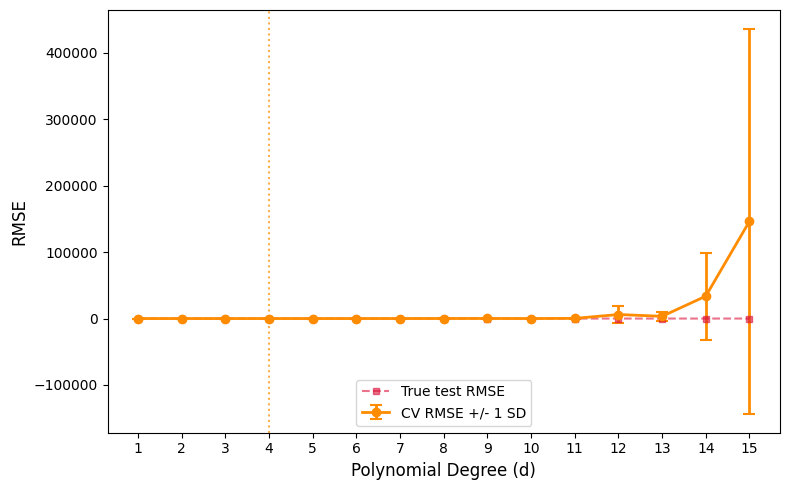

CV-selected degree: 4
True optimal degree: 5


In [9]:
all_degrees = range(1, 16)
cv_means = []
cv_stds = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    scores = cross_val_score(
        model, x_train.reshape(-1, 1), y_train,
        cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    cv_means.append(rmse_scores.mean())
    cv_stds.append(rmse_scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(list(all_degrees), cv_means, yerr=cv_stds,
            fmt='o-', color='darkorange', linewidth=2,
            markersize=6, capsize=4, capthick=1.5,
            label='CV RMSE +/- 1 SD')
ax.plot(list(all_degrees), test_errors, 's--', color='crimson',
        linewidth=1.5, markersize=4, alpha=0.6,
        label='True test RMSE')

cv_best_degree = list(all_degrees)[np.argmin(cv_means)]
ax.axvline(x=cv_best_degree, color='darkorange', linestyle=':',
           alpha=0.7)

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'CV-selected degree: {cv_best_degree}')
print(f'True optimal degree: {best_degree}')

In [10]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name='house_prices', version=1,
                    as_frame=True, parser='auto')
df_ames = ames.data.copy()
df_ames['SalePrice'] = ames.target.astype(float)

numeric_cols = df_ames.select_dtypes(
    include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')
df_numeric = df_ames[numeric_cols + ['SalePrice']].dropna()

X_ames = df_numeric[numeric_cols].values
y_ames = df_numeric['SalePrice'].values

print(f'Ames Housing: {X_ames.shape[0]} observations, '
      f'{X_ames.shape[1]} numeric features')
print(f'p/n ratio: {X_ames.shape[1] / X_ames.shape[0]:.3f}')

Ames Housing: 1121 observations, 37 numeric features
p/n ratio: 0.033


In [11]:
from sklearn.preprocessing import StandardScaler

# Approach 1: Kitchen sink - all features
kitchen_sink = make_pipeline(StandardScaler(), LinearRegression())

cv_kitchen = cross_val_score(
    kitchen_sink, X_ames, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_kitchen = np.sqrt(-cv_kitchen)
print(f'Kitchen sink (all {X_ames.shape[1]} features):')
print(f'  CV RMSE: {rmse_kitchen.mean():,.0f} '
      f'+/- {rmse_kitchen.std():,.0f}')

# Approach 2: Top 5 features by correlation
correlations = df_numeric.corr()['SalePrice'].drop(
    'SalePrice').abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
print(f'\nTop 5 features: {top_5_features}')

X_top5 = df_numeric[top_5_features].values
simple_model = make_pipeline(StandardScaler(), LinearRegression())

cv_simple = cross_val_score(
    simple_model, X_top5, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_simple = np.sqrt(-cv_simple)
print(f'\nSimple model (top 5 features):')
print(f'  CV RMSE: {rmse_simple.mean():,.0f} '
      f'+/- {rmse_simple.std():,.0f}')

Kitchen sink (all 37 features):
  CV RMSE: 38,871 +/- 8,515

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

Simple model (top 5 features):
  CV RMSE: 41,986 +/- 7,397


Reflection Question:

I would choose regularization models like Lasso or Ridge. Simple models often have high bias and underfitting problems, while very complex models have high variance and overfitting issues. Regularization can control variance without increasing excessive bias, thereby helping to improve generalization ability. I will use cross-validation to compare different models and select the one with the lowest validation error. The goal is to maintain a small generalization gap and obtain stable prediction results on new datasets.

In [15]:
# Install Streamlit
!pip install streamlit

"""
Bias-Variance Tradeoff Explorer — Lab 15 Interactive Dashboard
Run with: streamlit run bias_variance_dashboard.py
"""

import numpy as np
import streamlit as st
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# ── Page config ────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Bias-Variance Tradeoff Explorer",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ── Custom CSS ──────────────────────────────────────────────────────────────────
st.markdown("""
<style>
    .main > div { padding-top: 1rem; }
    h1 { font-size: 1.6rem !important; }
    h2 { font-size: 1.1rem !important; color: #555; }
    .metric-box {
        background: #f8f9fa; border-radius: 8px;
        padding: 0.6rem 1rem; margin: 0.3rem 0;
        border-left: 4px solid #4C72B0;
    }
    .stSlider > label { font-weight: 600; }
</style>
""", unsafe_allow_html=True)

# ── True function ───────────────────────────────────────────────────────────────
def true_fn(x):
    return np.sin(2 * np.pi * x)


# ── Data generation ─────────────────────────────────────────────────────────────
def generate_data(n_train, sigma, seed=42):
    rng = np.random.default_rng(seed)
    x_train = np.sort(rng.uniform(0, 1, n_train))
    y_train = true_fn(x_train) + rng.normal(0, sigma, n_train)
    x_test  = np.sort(rng.uniform(0, 1, 300))
    y_test  = true_fn(x_test)  + rng.normal(0, sigma, 300)
    return x_train, y_train, x_test, y_test


# ── Fit one polynomial model ────────────────────────────────────────────────────
def fit_poly(degree, x_train, y_train):
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    return model


# ── Complexity curve (train + test RMSE for all degrees) ──────────────────────
def complexity_curve(x_train, y_train, x_test, y_test, max_deg=15):
    train_rmse, test_rmse = [], []
    for d in range(1, max_deg + 1):
        m = fit_poly(d, x_train, y_train)
        train_rmse.append(np.sqrt(mean_squared_error(
            y_train, m.predict(x_train.reshape(-1, 1)))))
        test_rmse.append(np.sqrt(mean_squared_error(
            y_test, m.predict(x_test.reshape(-1, 1)))))
    return np.array(train_rmse), np.array(test_rmse)


# ── Bootstrap bias-variance decomposition ──────────────────────────────────────
@st.cache_data(show_spinner=False)
def bv_decomposition(n_train, sigma, max_deg=15, n_bootstrap=100):
    """
    Perform a bootstrap simulation to estimate bias, variance, and MSE.
    """
    x_grid = np.linspace(0, 1, 200)
    y_true = true_fn(x_grid)

    results = {}
    rng = np.random.default_rng(0)

    for d in range(1, max_deg + 1):
        preds = np.zeros((n_bootstrap, len(x_grid)))
        for b in range(n_bootstrap):
            x_b = np.sort(rng.uniform(0, 1, n_train))
            y_b = true_fn(x_b) + rng.normal(0, sigma, n_train)
            m = fit_poly(d, x_b, y_b)
            preds[b] = m.predict(x_grid.reshape(-1, 1))

        mean_pred  = preds.mean(axis=0)
        bias_sq    = np.mean((mean_pred - y_true) ** 2)
        variance   = np.mean(preds.var(axis=0))
        mse        = bias_sq + variance + sigma ** 2
        results[d] = dict(bias_sq=bias_sq, variance=variance, mse=mse)

    return results


# ── Sidebar controls ────────────────────────────────────────────────────────────
st.sidebar.title("⚙️ Controls")

degree = st.sidebar.slider("Polynomial Degree", 1, 15, 5)
sigma  = st.sidebar.slider("Noise Level (σ)", 0.1, 1.0, 0.3, step=0.05)
n_pts  = st.sidebar.slider("Training Points (n)", 20, 200, 50, step=10)

st.sidebar.markdown("---")
st.sidebar.markdown(
    "**Tip:** Increase degree to watch overfitting; "
    "decrease n to amplify the effect."
)

# ── Generate data & fit ─────────────────────────────────────────────────────────
x_train, y_train, x_test, y_test = generate_data(n_pts, sigma)
model   = fit_poly(degree, x_train, y_train)
x_plot  = np.linspace(0, 1, 300)
y_fit   = model.predict(x_plot.reshape(-1, 1))

train_rmse_now = np.sqrt(mean_squared_error(
    y_train, model.predict(x_train.reshape(-1, 1))))
test_rmse_now  = np.sqrt(mean_squared_error(
    y_test, model.predict(x_test.reshape(-1, 1))))

train_curve, test_curve = complexity_curve(x_train, y_train, x_test, y_test)

# ── Bias-variance decomp (cached) ──────────────────────────────────────────────
with st.spinner("Computing bias-variance decomposition (100 bootstrap samples)…"):
    bv = bv_decomposition(n_pts, sigma)

degrees_all = list(range(1, 16))
bias_vals   = [bv[d]["bias_sq"]  for d in degrees_all]
var_vals    = [bv[d]["variance"] for d in degrees_all]
mse_vals    = [bv[d]["mse"]      for d in degrees_all]

# ── Page header ────────────────────────────────────────────────────────────────
st.title("📈 Bias-Variance Tradeoff Explorer")
st.markdown(
    "Adjust the sliders to see how **polynomial degree**, **noise**, and "
    "**sample size** interact to determine model error."
)

# ── Metric strip ───────────────────────────────────────────────────────────────
c1, c2, c3, c4 = st.columns(4)
c1.metric("Degree",      degree)
c2.metric("Train RMSE",  f"{train_rmse_now:.4f}")
c3.metric("Test RMSE",   f"{test_rmse_now:.4f}",
          delta=f"{test_rmse_now - train_rmse_now:+.4f} vs train",
          delta_color="inverse")
c4.metric("Noise σ",     f"{sigma:.2f}  (σ²={sigma**2:.3f})")

st.markdown("---")

# ── FIGURE ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor("#0e1117")

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.42,
    wspace=0.32,
    left=0.07, right=0.97,
    top=0.93,  bottom=0.07
)

DARK_BG   = "#1a1d23"
GRID_COL  = "#2a2d35"
TEXT_COL  = "#e0e0e0"

BLUE   = "#4C9BE8"
ORANGE = "#F5A623"
GREEN  = "#50C878"
RED    = "#E85C5C"
PURPLE = "#A78BFA"

def style_ax(ax, title):
    ax.set_facecolor(DARK_BG)
    ax.set_title(title, color=TEXT_COL, fontsize=11, fontweight="bold", pad=8)
    ax.tick_params(colors=TEXT_COL, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)
    ax.xaxis.label.set_color(TEXT_COL)
    ax.yaxis.label.set_color(TEXT_COL)
    ax.grid(True, color=GRID_COL, linewidth=0.6, linestyle="--", alpha=0.7)


# ── Panel 1: Polynomial fit ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, f"Polynomial Fit — Degree {degree}")

ax1.scatter(x_train, y_train, color=BLUE, s=22, alpha=0.75, zorder=3,
            label=f"Train data (n={n_pts})")
ax1.plot(x_plot, true_fn(x_plot), color=GREEN, lw=2.2, label="True: sin(2πx)")
ax1.plot(x_plot, y_fit, color=ORANGE, lw=2, linestyle="--",
         label=f"Poly degree {degree}")

# Shade region between fit and truth
ax1.fill_between(x_plot, true_fn(x_plot), y_fit,
                 alpha=0.12, color=RED, label="Error region")

ax1.set_ylim(-2.5, 2.5)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
leg = ax1.legend(fontsize=7.5, loc="upper right",
                 facecolor="#252830", labelcolor=TEXT_COL,
                 edgecolor=GRID_COL)


# ── Panel 2: Complexity curve ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, "Complexity Curve (RMSE vs Degree)")

deg_range = list(range(1, 16))
ax2.plot(deg_range, train_curve, color=BLUE,   lw=2, marker="o",
         markersize=4, label="Train RMSE")
ax2.plot(deg_range, test_curve,  color=ORANGE, lw=2, marker="s",
         markersize=4, label="Test RMSE")
ax2.axvline(degree, color=RED, lw=1.8, linestyle=":", alpha=0.9,
            label=f"Selected degree={degree}")

best_deg = int(np.argmin(test_curve)) + 1
ax2.axvline(best_deg, color=GREEN, lw=1.4, linestyle="--", alpha=0.7,
            label=f"Best degree={best_deg}")

ax2.set_xlabel("Polynomial Degree")
ax2.set_ylabel("RMSE")
ax2.set_xticks(deg_range)
ax2.legend(fontsize=7.5, facecolor="#252830", labelcolor=TEXT_COL,
           edgecolor=GRID_COL)


# ── Panel 3: Bias² and Variance ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3, "Bias² & Variance vs Degree  (100 bootstrap samples)")

ax3.plot(degrees_all, bias_vals, color=RED,    lw=2, marker="o",
         markersize=4, label="Bias²")
ax3.plot(degrees_all, var_vals,  color=PURPLE, lw=2, marker="s",
         markersize=4, label="Variance")
ax3.plot(degrees_all, mse_vals,  color=ORANGE, lw=2, marker="^",
         markersize=4, linestyle="--", label="Bias²+Var+σ² (≈MSE)")
ax3.axhline(sigma**2, color=GRID_COL, lw=1.2, linestyle=":",
            label=f"Irreducible noise σ²={sigma**2:.3f}")
ax3.axvline(degree, color=RED, lw=1.4, linestyle=":", alpha=0.8)

ax3.set_xlabel("Polynomial Degree")
ax3.set_ylabel("Error")
ax3.set_xticks(degrees_all)
ax3.legend(fontsize=7.5, facecolor="#252830", labelcolor=TEXT_COL,
           edgecolor=GRID_COL)


# ── Panel 4: Stacked bias-variance bar ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4, "MSE Decomposition  (Stacked, Bootstrap)")

bar_w = 0.65
noise_arr = [sigma**2] * len(degrees_all)

b1 = ax4.bar(degrees_all, bias_vals, bar_w,
             color=RED,    alpha=0.85, label="Bias²")
b2 = ax4.bar(degrees_all, var_vals, bar_w,
             bottom=bias_vals,
             color=PURPLE, alpha=0.85, label="Variance")
b3 = ax4.bar(degrees_all, noise_arr, bar_w,
             bottom=np.array(bias_vals) + np.array(var_vals),
             color=GRID_COL, alpha=0.6, label=f"σ²={sigma**2:.3f}")

ax4.axvline(degree, color=ORANGE, lw=1.8, linestyle=":",
            label=f"Degree={degree}")

ax4.set_xlabel("Polynomial Degree")
ax4.set_ylabel("Total MSE")
ax4.set_xticks(degrees_all)
ax4.legend(fontsize=7.5, facecolor="#252830", labelcolor=TEXT_COL,
           edgecolor=GRID_COL)

st.pyplot(fig, use_container_width=True)
plt.close(fig)

# ── Decomp table for selected degree ───────────────────────────────────────────
st.markdown("---")
st.subheader(f"📊 Decomposition at Degree {degree}")

sel = bv[degree]
total = sel["bias_sq"] + sel["variance"] + sigma**2
t1, t2, t3, t4 = st.columns(4)
t1.metric("Bias²",          f"{sel['bias_sq']:.4f}",
          f"{sel['bias_sq']/total*100:.1f}% of MSE")
t2.metric("Variance",       f"{sel['variance']:.4f}",
          f"{sel['variance']/total*100:.1f}% of MSE")
t3.metric("Irreducible σ²", f"{sigma**2:.4f}",
          f"{sigma**2/total*100:.1f}% of MSE")
t4.metric("Total MSE",      f"{total:.4f}")

verify_ok = abs(sel["mse"] - total) < 1e-9
st.success(f"✓ Bias² + Variance + σ²  =  {total:.4f}  ≈  MSE  ({sel['mse']:.4f}). "
           f"Decomposition verified.")

# ── Explanation footer ──────────────────────────────────────────────────────────
with st.expander("📖 How the math works"):
    st.markdown(r"""
**True function:** $y = \sin(2\pi x) + \varepsilon$, where $\varepsilon \sim \mathcal{N}(0, \sigma^2)$.

**Bias-Variance Decomposition:**

$$\text{MSE}(\hat{f}) = \underbrace{\left(\mathbb{E}[\hat{f}(x)] - f(x)\right)^2}_{\text{Bias}^2} + \underbrace{\text{Var}[\hat{f}(x)]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible}}$$

**Estimation procedure (bootstrap):**
1. Draw 100 independent training sets of size $n$ from the same DGP.
2. Fit the polynomial of chosen degree on each.
3. Collect all 100 predictions on a fixed grid $x \in [0,1]$.
4. **Bias²** = average squared gap between mean prediction and true function.
5. **Variance** = average prediction variance across the 100 models.

**Key insight:** As degree ↑, bias ↓ but variance ↑. The sweet spot minimises *total* test error.
""")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 105.4 MB/s eta 0:00:00


2026-03-29 11:03:52.173 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:03:52.175 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:03:52.326 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-29 11:03:52.327 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:03:52.328 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:03:52.332 No runtime found, using MemoryCacheStorageManager
2026-03-29 11:03:52.336 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:03:52.337 Thread 'Ma